In [1]:
import pandas as pd
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    GroupShuffleSplit, StratifiedShuffleSplit,
    RandomizedSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from xgboost import XGBClassifier
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print('✅ Import xong!')

✅ Import xong!


In [2]:
df1 = pd.read_csv('/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data/features_3_sec.csv')
df2 = pd.read_csv('/kaggle/input/datasets/titeohihi/homemade-features-3-sec/features_3_sec.csv')

# Tạo cột original_file từ filename
# df1: blues.00000.0.wav  → blues.00000  (bỏ .segment.wav)
# df2: blues.00000.00     → blues.00000  (bỏ .segment)
df1['original_file'] = df1['filename'].str.rsplit('.', n=2).str[0]
df2['original_file'] = df2['filename'].str.rsplit('.', n=1).str[0]

for name, df in [('Dataset gốc (df1)', df1), ('Dataset tự tạo (df2)', df2)]:
    print(f'{name}: {df.shape[0]} dòng × {df.shape[1]} cột')
    print(f'  Số bài nhạc độc lập : {df["original_file"].nunique()}')
    print(f'  Phân phối genre     : {dict(df["label"].value_counts().sort_index())}\n')

Dataset gốc (df1): 9990 dòng × 61 cột
  Số bài nhạc độc lập : 1000
  Phân phối genre     : {'blues': np.int64(1000), 'classical': np.int64(998), 'country': np.int64(997), 'disco': np.int64(999), 'hiphop': np.int64(998), 'jazz': np.int64(1000), 'metal': np.int64(1000), 'pop': np.int64(1000), 'reggae': np.int64(1000), 'rock': np.int64(998)}

Dataset tự tạo (df2): 9981 dòng × 61 cột
  Số bài nhạc độc lập : 999
  Phân phối genre     : {'blues': np.int64(1000), 'classical': np.int64(998), 'country': np.int64(997), 'disco': np.int64(999), 'hiphop': np.int64(998), 'jazz': np.int64(990), 'metal': np.int64(1000), 'pop': np.int64(1000), 'reggae': np.int64(1000), 'rock': np.int64(999)}



In [3]:
print('PREPROCESSING')

def preprocess(df, test_size=0.15, val_size=0.15, random_state=RANDOM_SEED):
    """
    Split Train(~70%) / Val(~15%) / Test(~15%) theo group 'original_file'.
    - GroupShuffleSplit: các đoạn 3 giây của cùng bài nhạc chỉ nằm trong 1 tập.
    - Scaler fit CHỈ trên train, transform val và test.
    - Nếu không có 'original_file', fallback về StratifiedShuffleSplit.
    """
    meta_cols = ['filename', 'length']
    group_col = 'original_file'

    # ── Check group TRƯỚC khi drop ───────────────────────────────────────────
    has_group = group_col in df.columns
    if not has_group:
        print('  ⚠️  Không tìm thấy cột "original_file" — fallback về StratifiedShuffleSplit.')

    feature_df    = df.drop(columns=[c for c in meta_cols if c in df.columns])
    le            = LabelEncoder()
    y             = le.fit_transform(feature_df['label'])
    X             = feature_df.drop(columns=['label', group_col], errors='ignore').values.astype(np.float32)
    feature_names = feature_df.drop(columns=['label', group_col], errors='ignore').columns.tolist()

    # ── Bước 1: Tách test ────────────────────────────────────────────────────
    if has_group:
        groups   = df[group_col].values
        gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
        trainval_idx, test_idx = next(gss_test.split(X, y, groups=groups))
    else:
        sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
        trainval_idx, test_idx = next(sss.split(X, y))

    X_trainval, X_test = X[trainval_idx], X[test_idx]
    y_trainval, y_test = y[trainval_idx], y[test_idx]

    # ── Bước 2: Tách val từ train+val ────────────────────────────────────────
    val_ratio = val_size / (1 - test_size)

    if has_group:
        groups_trainval = groups[trainval_idx]
        gss_val = GroupShuffleSplit(n_splits=1, test_size=val_ratio, random_state=random_state)
        train_idx2, val_idx2 = next(gss_val.split(X_trainval, y_trainval, groups=groups_trainval))
    else:
        sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_ratio, random_state=random_state)
        train_idx2, val_idx2 = next(sss2.split(X_trainval, y_trainval))

    X_train, X_val = X_trainval[train_idx2], X_trainval[val_idx2]
    y_train, y_val = y_trainval[train_idx2], y_trainval[val_idx2]

    # ── Scale — fit chỉ trên train ───────────────────────────────────────────
    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc   = scaler.transform(X_val)
    X_test_sc  = scaler.transform(X_test)

    total        = len(y)
    split_method = 'GroupShuffleSplit (theo bài nhạc)' if has_group else 'StratifiedShuffleSplit'
    print(f'  Phương pháp split : {split_method}')
    print(f'  Train : {len(y_train):5d} ({len(y_train)/total*100:.1f}%)')
    print(f'  Val   : {len(y_val):5d} ({len(y_val)/total*100:.1f}%)')
    print(f'  Test  : {len(y_test):5d} ({len(y_test)/total*100:.1f}%)')

    # ── Kiểm tra overlap ─────────────────────────────────────────────────────
    if has_group:
        train_songs = set(groups[trainval_idx][train_idx2])
        val_songs   = set(groups[trainval_idx][val_idx2])
        test_songs  = set(groups[test_idx])
        overlap_tv  = train_songs & val_songs
        overlap_tt  = train_songs & test_songs
        overlap_vt  = val_songs   & test_songs
        if overlap_tv or overlap_tt or overlap_vt:
            print(f'  ❌ Overlap! TV={len(overlap_tv)}, TT={len(overlap_tt)}, VT={len(overlap_vt)}')
        else:
            print(f'  ✅ Không overlap ({len(set(groups))} bài độc lập)')

    # ── Kiểm tra phân phối label trong test ──────────────────────────────────
    unique, counts = np.unique(y_test, return_counts=True)
    min_count = counts.min()
    if min_count < 5:
        print(f'  ⚠️  Một số genre có < 5 samples trong test set (min={min_count}). Kết quả có thể không ổn định.')
    else:
        print(f'  ✅ Phân phối test set ổn (min per genre = {min_count})')

    return {
        'X_train': X_train_sc, 'X_val': X_val_sc, 'X_test': X_test_sc,
        'y_train': y_train,    'y_val': y_val,     'y_test': y_test,
        'le': le, 'scaler': scaler,
        'feature_names': feature_names
    }

print('\n--- Dataset gốc ---')
d1 = preprocess(df1)
print('\n--- Dataset tự tạo ---')
d2 = preprocess(df2)

PREPROCESSING

--- Dataset gốc ---
  Phương pháp split : GroupShuffleSplit (theo bài nhạc)
  Train :  6992 (70.0%)
  Val   :  1500 (15.0%)
  Test  :  1498 (15.0%)
  ✅ Không overlap (1000 bài độc lập)
  ✅ Phân phối test set ổn (min per genre = 89)

--- Dataset tự tạo ---
  Phương pháp split : GroupShuffleSplit (theo bài nhạc)
  Train :  6983 (70.0%)
  Val   :  1500 (15.0%)
  Test  :  1498 (15.0%)
  ✅ Không overlap (999 bài độc lập)
  ✅ Phân phối test set ổn (min per genre = 99)


In [4]:
baseline_models = {
    'KNN'          : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=20,
                                             n_jobs=-1, random_state=RANDOM_SEED),
    'SVM'          : SVC(kernel='rbf', C=10, gamma='scale',
                         probability=True, random_state=RANDOM_SEED),
    'XGBoost'      : XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                    n_jobs=-1, eval_metric='mlogloss',
                                    random_state=RANDOM_SEED, verbosity=0),
}

def run_baseline(data, label):
    print(f'\n{"="*50}')
    print(f'  BASELINE — {label}')
    print(f'{"="*50}')
    results = {}
    for name, model in baseline_models.items():
        m = copy.deepcopy(model)
        m.fit(data['X_train'], data['y_train'])
        train_acc = accuracy_score(data['y_train'], m.predict(data['X_train']))
        val_acc   = accuracy_score(data['y_val'],   m.predict(data['X_val']))
        val_f1    = f1_score(data['y_val'], m.predict(data['X_val']), average='macro')
        gap       = train_acc - val_acc
        overfit   = '⚠️ overfit' if gap > 0.10 else '✅'
        results[name] = {'model': m, 'val_acc': val_acc, 'val_f1': val_f1, 'gap': gap}
        print(f'  {name:<15} Train: {train_acc:.4f}  Val: {val_acc:.4f}  Gap: {gap:.4f}  {overfit}')
    best = max(results, key=lambda k: results[k]['val_acc'])
    print(f'  → Best (Val): {best} ({results[best]["val_acc"]:.4f})')
    return results

baseline1 = run_baseline(d1, 'Dataset gốc')
baseline2 = run_baseline(d2, 'Dataset tự tạo')


  BASELINE — Dataset gốc
  KNN             Train: 0.9464  Val: 0.6467  Gap: 0.2997  ⚠️ overfit
  Random Forest   Train: 0.9986  Val: 0.7367  Gap: 0.2619  ⚠️ overfit
  SVM             Train: 0.9973  Val: 0.7487  Gap: 0.2486  ⚠️ overfit
  XGBoost         Train: 0.9986  Val: 0.7727  Gap: 0.2259  ⚠️ overfit
  → Best (Val): XGBoost (0.7727)

  BASELINE — Dataset tự tạo
  KNN             Train: 0.9489  Val: 0.6387  Gap: 0.3102  ⚠️ overfit
  Random Forest   Train: 1.0000  Val: 0.6627  Gap: 0.3373  ⚠️ overfit
  SVM             Train: 0.9981  Val: 0.7240  Gap: 0.2741  ⚠️ overfit
  XGBoost         Train: 1.0000  Val: 0.7100  Gap: 0.2900  ⚠️ overfit
  → Best (Val): SVM (0.7240)


In [5]:
# ── Định nghĩa search space ──────────────────────────────
# Dùng CV=3 trên train set để tìm params, sau đó đánh giá trên val

param_grids = {
    'KNN': {
        'model': KNeighborsClassifier(n_jobs=-1),
        'params': {
            'n_neighbors': [3, 5, 7, 11, 15],
            'weights'    : ['uniform', 'distance'],
            'metric'     : ['euclidean', 'manhattan']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(n_jobs=-1, random_state=RANDOM_SEED),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth'   : [None, 20, 30],
            'max_features': ['sqrt', 'log2'],
            'min_samples_split': [2, 5]
        }
    },
    'SVM': {
        'model': SVC(kernel='rbf', probability=True, random_state=RANDOM_SEED),
        'params': {
            'C'    : [1, 5, 10, 50, 100],
            'gamma': ['scale', 'auto', 0.001, 0.01]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(n_jobs=-1, eval_metric='mlogloss',
                                random_state=RANDOM_SEED, verbosity=0),
        'params': {
            'n_estimators' : [100, 200, 300],
            'max_depth'    : [4, 6, 8],
            'learning_rate': [0.05, 0.1, 0.2],
            'subsample'    : [0.8, 1.0]
        }
    }
}

def run_grid_search(data, label):
    print(f'\n{'='*55}')
    print(f'  GRID SEARCH — {label}')
    print(f'{'='*55}')
    tuned_results = {}

    for name, cfg in param_grids.items():
        print(f'\n  🔍 Tuning {name}...')

        gs = GridSearchCV(
            cfg['model'], cfg['params'],
            cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED),
            scoring='accuracy', n_jobs=-1, verbose=0
        )
        gs.fit(data['X_train'], data['y_train'])

        # Đánh giá best model trên Val set
        best_model = gs.best_estimator_
        val_pred   = best_model.predict(data['X_val'])
        val_acc    = accuracy_score(data['y_val'], val_pred)
        val_f1     = f1_score(data['y_val'], val_pred, average='macro')

        tuned_results[name] = {
            'model'     : best_model,
            'best_params': gs.best_params_,
            'cv_acc'    : gs.best_score_,
            'val_acc'   : val_acc,
            'val_f1'    : val_f1
        }

        print(f'     Best params : {gs.best_params_}')
        print(f'     CV Acc      : {gs.best_score_:.4f}')
        print(f'     Val Acc     : {val_acc:.4f}  |  Val F1: {val_f1:.4f}')

    best_name = max(tuned_results, key=lambda k: tuned_results[k]['val_acc'])
    print(f'\n  🏆 Best sau tuning (Val): {best_name} ({tuned_results[best_name]["val_acc"]:.4f})')
    return tuned_results

print('⏳ Đang chạy Grid Search (mất 5-15 phút)...')
tuned1 = run_grid_search(d1, 'Dataset gốc')
tuned2 = run_grid_search(d2, 'Dataset tự tạo')

⏳ Đang chạy Grid Search (mất 5-15 phút)...

  GRID SEARCH — Dataset gốc

  🔍 Tuning KNN...
     Best params : {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
     CV Acc      : 0.9208
     Val Acc     : 0.6567  |  Val F1: 0.6587

  🔍 Tuning Random Forest...
     Best params : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
     CV Acc      : 0.8706
     Val Acc     : 0.7393  |  Val F1: 0.7327

  🔍 Tuning SVM...
     Best params : {'C': 100, 'gamma': 'scale'}
     CV Acc      : 0.9065
     Val Acc     : 0.7447  |  Val F1: 0.7445

  🔍 Tuning XGBoost...
     Best params : {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
     CV Acc      : 0.8955
     Val Acc     : 0.7733  |  Val F1: 0.7735

  🏆 Best sau tuning (Val): XGBoost (0.7733)

  GRID SEARCH — Dataset tự tạo

  🔍 Tuning KNN...
     Best params : {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
     CV Acc      : 0.9228
     Val Ac

In [6]:
def compare_baseline_tuned(baseline, tuned, dataset_label):
    print(f'\n{'='*65}')
    print(f'  SO SÁNH BASELINE vs TUNED — {dataset_label} (Val set)')
    print(f'{'='*65}')
    print(f'  {'Model':<18} {'Baseline':>10} {'Tuned':>10} {'Δ':>8}')
    print(f'  {'-'*50}')
    for name in baseline:
        b = baseline[name]['val_acc']
        t = tuned[name]['val_acc']
        delta = t - b
        arrow = '↑' if delta > 0 else ('↓' if delta < 0 else '=')
        print(f'  {name:<18} {b:>10.4f} {t:>10.4f} {arrow}{abs(delta):>6.4f}')

compare_baseline_tuned(baseline1, tuned1, 'Dataset gốc')
compare_baseline_tuned(baseline2, tuned2, 'Dataset tự tạo')


  SO SÁNH BASELINE vs TUNED — Dataset gốc (Val set)
  Model                Baseline      Tuned        Δ
  --------------------------------------------------
  KNN                    0.6467     0.6567 ↑0.0100
  Random Forest          0.7367     0.7393 ↑0.0027
  SVM                    0.7487     0.7447 ↓0.0040
  XGBoost                0.7727     0.7733 ↑0.0007

  SO SÁNH BASELINE vs TUNED — Dataset tự tạo (Val set)
  Model                Baseline      Tuned        Δ
  --------------------------------------------------
  KNN                    0.6387     0.6387 =0.0000
  Random Forest          0.6627     0.6540 ↓0.0087
  SVM                    0.7240     0.7240 =0.0000
  XGBoost                0.7100     0.7293 ↑0.0193


In [7]:
def final_evaluation(tuned, data, dataset_label):
    print(f'\n{'='*60}')
    print(f'  FINAL TEST SET EVALUATION — {dataset_label}')
    print(f'{'='*60}')

    final_results = {}
    for name, res in tuned.items():
        model     = res['model']
        test_pred = model.predict(data['X_test'])
        test_acc  = accuracy_score(data['y_test'], test_pred)
        test_f1_m = f1_score(data['y_test'], test_pred, average='macro')
        test_f1_w = f1_score(data['y_test'], test_pred, average='weighted')
        final_results[name] = {
            'test_acc' : test_acc,
            'test_f1_m': test_f1_m,
            'test_f1_w': test_f1_w,
            'test_pred': test_pred
        }
        print(f'  {name:<15}  Acc: {test_acc:.4f}  F1_macro: {test_f1_m:.4f}  F1_weighted: {test_f1_w:.4f}')

    best_name = max(final_results, key=lambda k: final_results[k]['test_acc'])
    best      = final_results[best_name]
    print(f'\n  🏆 Best model: {best_name} (Test Acc = {best["test_acc"]:.4f})')
    print(f'\n  Classification Report ({best_name}):')
    print(classification_report(
        data['y_test'], best['test_pred'],
        target_names=data['le'].classes_
    ))
    return final_results, best_name

final1, best1 = final_evaluation(tuned1, d1, 'Dataset gốc')
final2, best2 = final_evaluation(tuned2, d2, 'Dataset tự tạo')


  FINAL TEST SET EVALUATION — Dataset gốc
  KNN              Acc: 0.6509  F1_macro: 0.6497  F1_weighted: 0.6515
  Random Forest    Acc: 0.7076  F1_macro: 0.7024  F1_weighted: 0.7002
  SVM              Acc: 0.6963  F1_macro: 0.6850  F1_weighted: 0.6910
  XGBoost          Acc: 0.7316  F1_macro: 0.7299  F1_weighted: 0.7254

  🏆 Best model: XGBoost (Test Acc = 0.7316)

  Classification Report (XGBoost):
              precision    recall  f1-score   support

       blues       0.72      0.78      0.75       180
   classical       0.91      0.99      0.95        90
     country       0.73      0.74      0.74       220
       disco       0.63      0.81      0.71       120
      hiphop       0.68      0.71      0.70        89
        jazz       0.90      0.88      0.89       200
       metal       0.79      0.91      0.84       150
         pop       0.68      0.65      0.67       110
      reggae       0.68      0.42      0.52       180
        rock       0.55      0.53      0.54       159



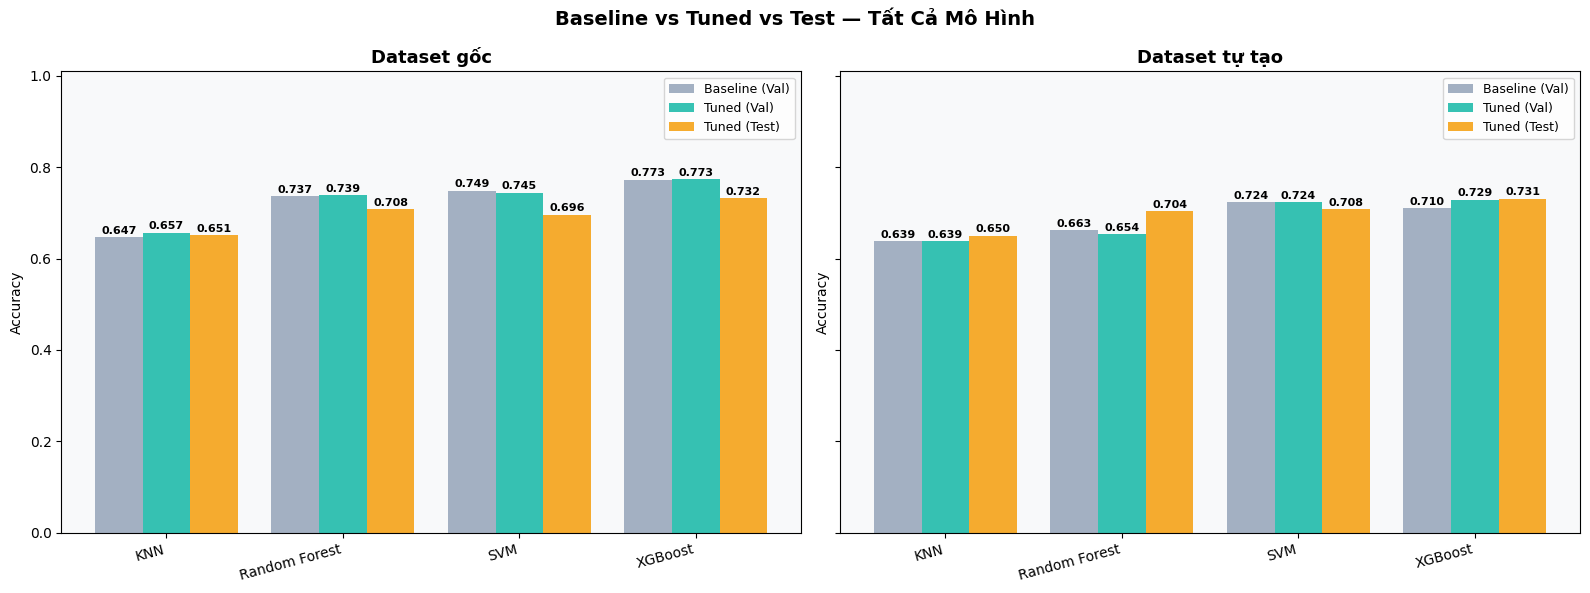

In [8]:
model_names = list(tuned1.keys())

# ── Bar chart so sánh 4 nhóm ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, baseline, tuned, final, label in [
    (axes[0], baseline1, tuned1, final1, 'Dataset gốc'),
    (axes[1], baseline2, tuned2, final2, 'Dataset tự tạo')
]:
    x     = np.arange(len(model_names))
    w     = 0.27
    base_accs  = [baseline[n]['val_acc']  for n in model_names]
    tuned_accs = [tuned[n]['val_acc']     for n in model_names]
    test_accs  = [final[n]['test_acc']    for n in model_names]

    b1 = ax.bar(x - w,   base_accs,  w, label='Baseline (Val)', color='#94A3B8', alpha=0.85)
    b2 = ax.bar(x,       tuned_accs, w, label='Tuned (Val)',     color='#14B8A6', alpha=0.85)
    b3 = ax.bar(x + w,   test_accs,  w, label='Tuned (Test)',    color='#F59E0B', alpha=0.85)

    for bars in [b1, b2, b3]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_ylim(0.0, 1.01)
    ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=15, ha='right')
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylabel('Accuracy'); ax.legend(fontsize=9)
    ax.set_facecolor('#f8f9fa')

plt.suptitle('Baseline vs Tuned vs Test — Tất Cả Mô Hình', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()

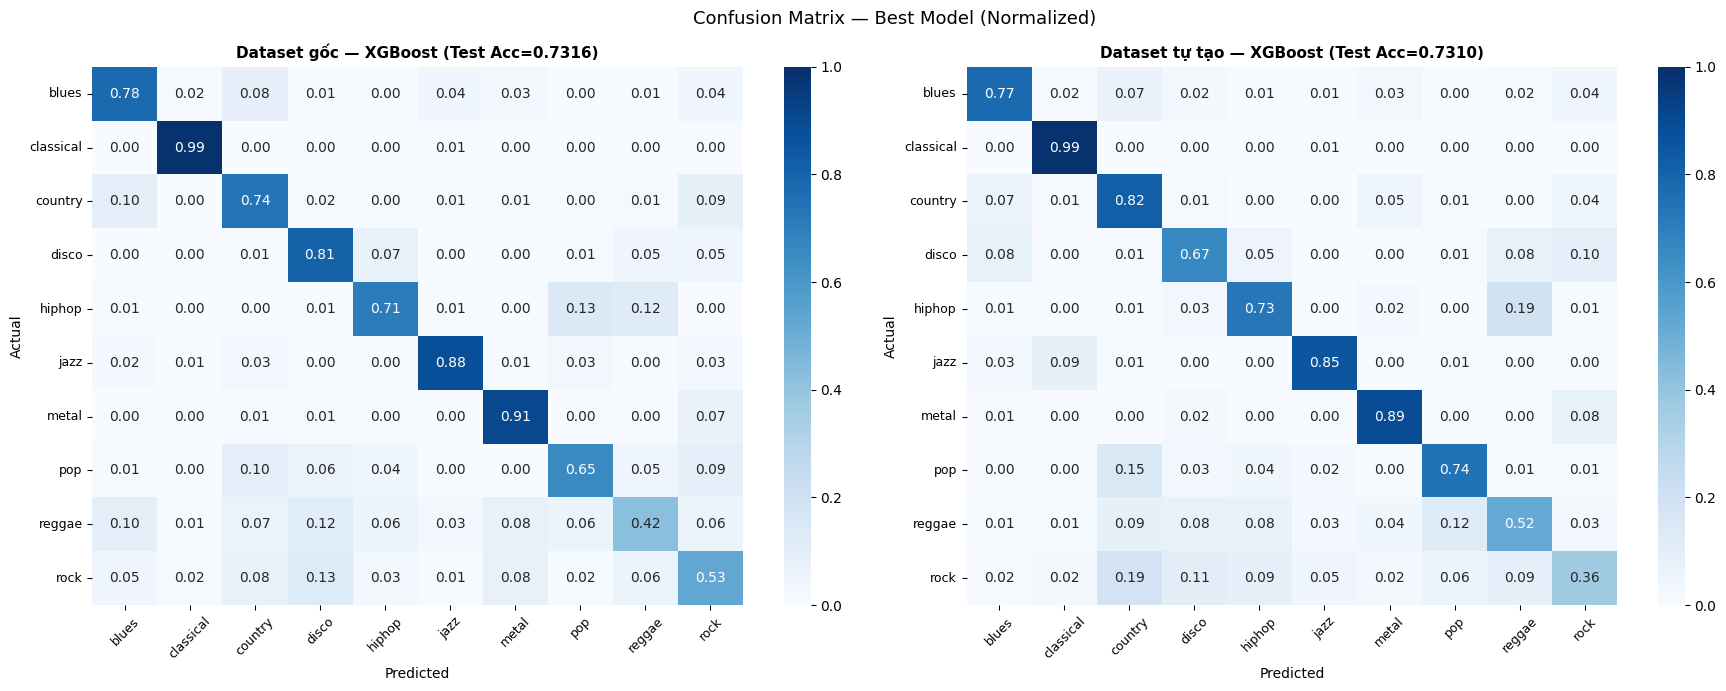

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, final, data, best_name, label in [
    (axes[0], final1, d1, best1, 'Dataset gốc'),
    (axes[1], final2, d2, best2, 'Dataset tự tạo')
]:
    cm      = confusion_matrix(data['y_test'], final[best_name]['test_pred'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=data['le'].classes_,
                yticklabels=data['le'].classes_,
                ax=ax, vmin=0, vmax=1)
    acc = final[best_name]['test_acc']
    ax.set_title(f'{label} — {best_name} (Test Acc={acc:.4f})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.suptitle('Confusion Matrix — Best Model (Normalized)', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
rows = []
for name in model_names:
    rows.append({
        'Model'         : name,
        'DS1 Baseline'  : f"{baseline1[name]['val_acc']:.4f}",
        'DS1 Tuned Val' : f"{tuned1[name]['val_acc']:.4f}",
        'DS1 Test'      : f"{final1[name]['test_acc']:.4f}",
        'DS2 Baseline'  : f"{baseline2[name]['val_acc']:.4f}",
        'DS2 Tuned Val' : f"{tuned2[name]['val_acc']:.4f}",
        'DS2 Test'      : f"{final2[name]['test_acc']:.4f}",
    })

df_summary = pd.DataFrame(rows)
df_summary.to_csv('/kaggle/working/final_summary.csv', index=False)

print('\n📊 BẢNG TỔNG KẾT CUỐI CÙNG')
print('='*85)
print(df_summary.to_string(index=False))
print('='*85)

# Highlight best
best_overall_ds1 = max(final1, key=lambda k: final1[k]['test_acc'])
best_overall_ds2 = max(final2, key=lambda k: final2[k]['test_acc'])
print(f'\n🏆 Dataset gốc    — Best: {best_overall_ds1} (Test={final1[best_overall_ds1]["test_acc"]:.4f})')
print(f'🏆 Dataset tự tạo — Best: {best_overall_ds2} (Test={final2[best_overall_ds2]["test_acc"]:.4f})')
print(f'\n✅ Đã lưu: final_summary.csv, comparison_all.png, confusion_matrices.png')


📊 BẢNG TỔNG KẾT CUỐI CÙNG
        Model DS1 Baseline DS1 Tuned Val DS1 Test DS2 Baseline DS2 Tuned Val DS2 Test
          KNN       0.6467        0.6567   0.6509       0.6387        0.6387   0.6502
Random Forest       0.7367        0.7393   0.7076       0.6627        0.6540   0.7043
          SVM       0.7487        0.7447   0.6963       0.7240        0.7240   0.7076
      XGBoost       0.7727        0.7733   0.7316       0.7100        0.7293   0.7310

🏆 Dataset gốc    — Best: XGBoost (Test=0.7316)
🏆 Dataset tự tạo — Best: XGBoost (Test=0.7310)

✅ Đã lưu: final_summary.csv, comparison_all.png, confusion_matrices.png


In [11]:
import pickle, os

SAVE_DIR = '/kaggle/working/models'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Lưu 4 tuned models × 2 datasets ─────────────────────────────────────────
for name, res in tuned1.items():
    fname = name.lower().replace(' ', '_')
    with open(f'{SAVE_DIR}/ds1_{fname}.pkl', 'wb') as f:
        pickle.dump(res['model'], f)

for name, res in tuned2.items():
    fname = name.lower().replace(' ', '_')
    with open(f'{SAVE_DIR}/ds2_{fname}.pkl', 'wb') as f:
        pickle.dump(res['model'], f)

# ── Lưu Stacking Ensemble (chỉ nếu đã train) ─────────────────────────────────
try:
    with open(f'{SAVE_DIR}/ds1_stacking.pkl', 'wb') as f:
        pickle.dump(stack1, f)
    with open(f'{SAVE_DIR}/ds2_stacking.pkl', 'wb') as f:
        pickle.dump(stack2, f)
    print('✅ Đã lưu Stacking Ensemble')
except NameError:
    print('⚠️  stack1/stack2 chưa được train — bỏ qua, chạy cell Stacking trước.')

# ── Lưu scaler + label encoder ───────────────────────────────────────────────
with open(f'{SAVE_DIR}/ds1_scaler.pkl', 'wb') as f:
    pickle.dump(d1['scaler'], f)
with open(f'{SAVE_DIR}/ds1_label_encoder.pkl', 'wb') as f:
    pickle.dump(d1['le'], f)

with open(f'{SAVE_DIR}/ds2_scaler.pkl', 'wb') as f:
    pickle.dump(d2['scaler'], f)
with open(f'{SAVE_DIR}/ds2_label_encoder.pkl', 'wb') as f:
    pickle.dump(d2['le'], f)

# ── Liệt kê file đã lưu ──────────────────────────────────────────────────────
print('\n📁 Files đã lưu:\n')
for fname in sorted(os.listdir(SAVE_DIR)):
    size_kb = os.path.getsize(f'{SAVE_DIR}/{fname}') / 1024
    print(f'  {fname:<35} {size_kb:>8.1f} KB')

⚠️  stack1/stack2 chưa được train — bỏ qua, chạy cell Stacking trước.

📁 Files đã lưu:

  ds1_knn.pkl                           1612.2 KB
  ds1_label_encoder.pkl                    0.3 KB
  ds1_random_forest.pkl               100022.1 KB
  ds1_scaler.pkl                           1.8 KB
  ds1_stacking.pkl                         0.0 KB
  ds1_svm.pkl                           2278.5 KB
  ds1_xgboost.pkl                       6149.0 KB
  ds2_knn.pkl                           1610.1 KB
  ds2_label_encoder.pkl                    0.3 KB
  ds2_random_forest.pkl                98590.3 KB
  ds2_scaler.pkl                           1.8 KB
  ds2_svm.pkl                           2245.7 KB
  ds2_xgboost.pkl                       3951.5 KB
